In [36]:
import pandas as pd

In [33]:
df = pd.read_csv('../data/dataset/ettm2.csv')
df

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000
2,2016-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002
3,2016-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001
4,2016-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001
...,...,...,...,...,...,...,...,...
69675,2018-06-26 18:45:00,42.722000,12.230,54.014000,12.652,-11.525,-1.418,45.986500
69676,2018-06-26 19:00:00,38.868000,10.052,49.859001,10.669,-11.525,-1.418,45.986500
69677,2018-06-26 19:15:00,39.622002,11.057,50.448002,11.795,-10.299,-1.418,45.546501
69678,2018-06-26 19:30:00,40.459999,11.392,51.841999,11.929,-11.536,-1.418,45.546501


In [34]:
df = df.iloc[:50000]
df

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000
2,2016-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002
3,2016-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001
4,2016-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001
...,...,...,...,...,...,...,...,...
49995,2017-12-03 18:45:00,40.292000,0.000,47.660999,4.182,-6.589,-1.791,19.326000
49996,2017-12-03 19:00:00,34.176998,0.000,41.467999,1.394,-7.815,-3.007,19.106501
49997,2017-12-03 19:15:00,32.167000,0.000,40.611000,0.000,-7.719,-3.007,18.886999
49998,2017-12-03 19:30:00,32.250999,0.000,40.584000,0.000,-8.945,-1.770,18.667000


In [35]:
df.to_csv('./dataset/ettm2.csv',index=False)

In [1]:
import numpy as np

In [2]:
pre = np.load('../results1/ETTh2_720_96_ADF_ETTh2_ftS_sl720_ll48_pl96_dm16_nh4_el3_dl1_df128_fc1_ebtimeF_dtTrue_Exp_0/pred.npy', allow_pickle=True)
pre.shape

(625, 96, 1)

In [46]:
weights = np.load('../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/moe_weights_period_0.npy', allow_pickle=True)
weights.shape

(11425, 7, 2)

图像已保存至: moe_analysis.png


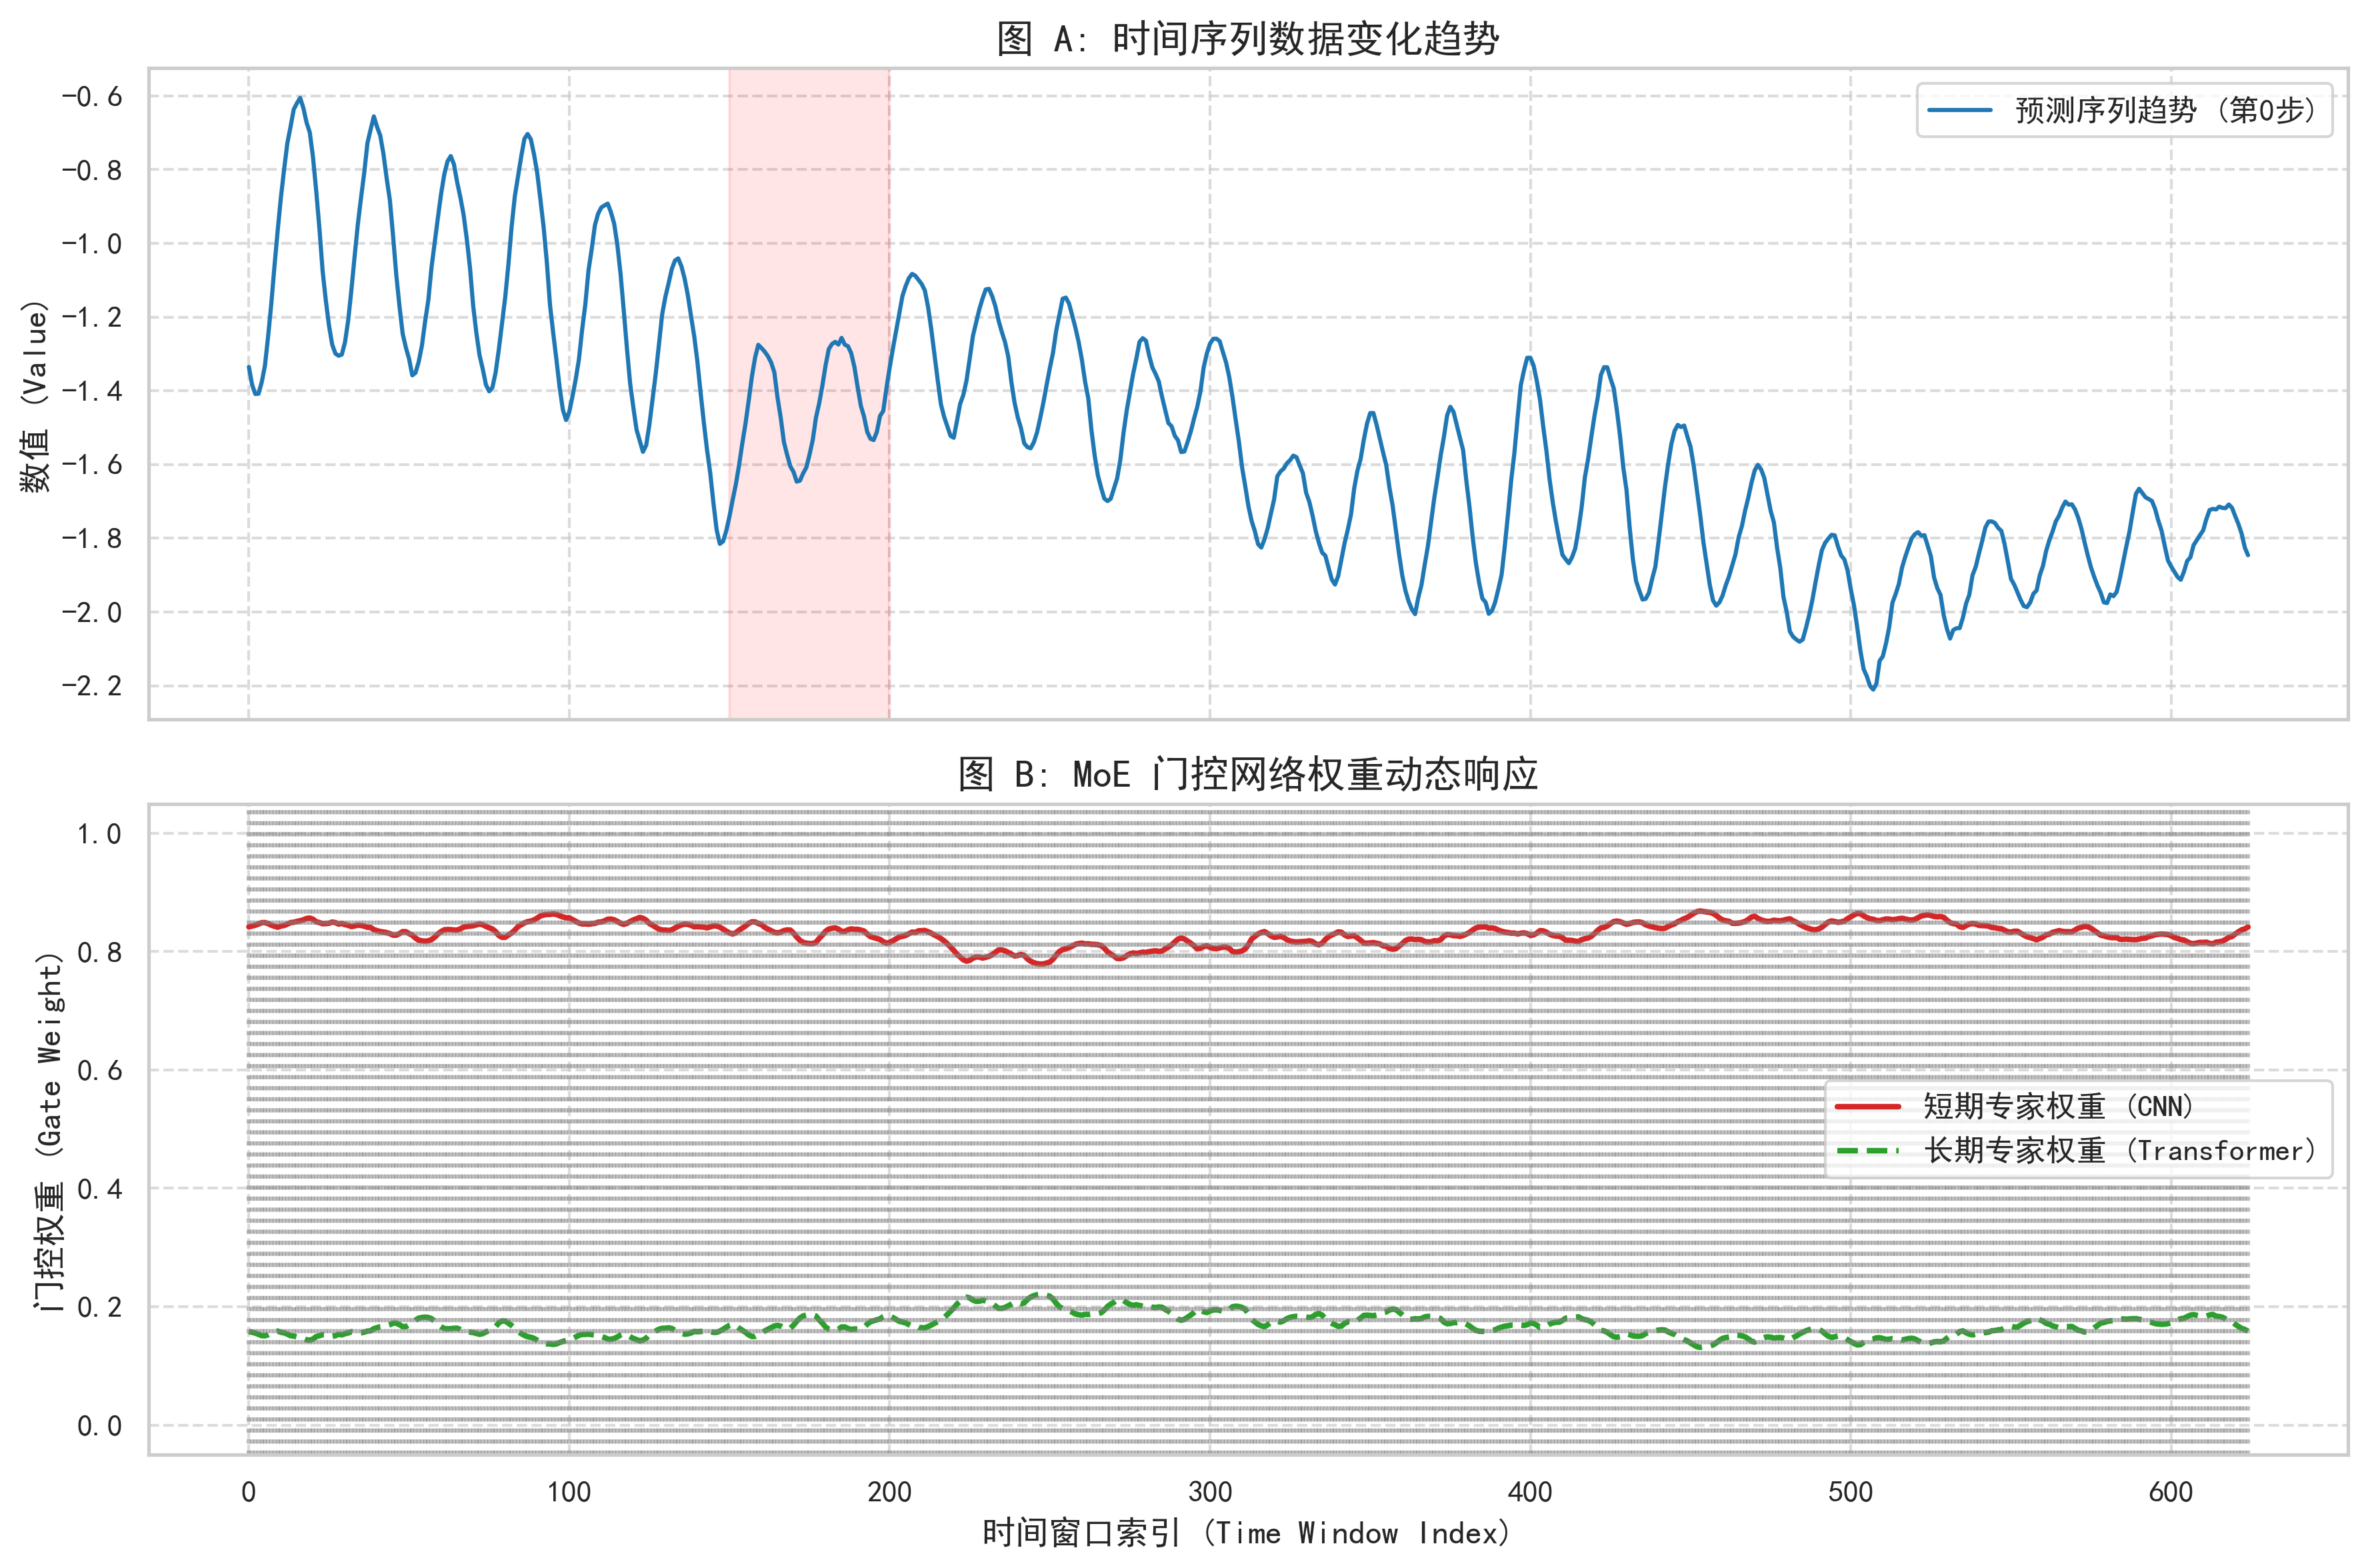

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 设置风格，符合论文要求
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

def plot_weight_analysis(pre, weights, save_path=None):
    """
    pre: (625, 96, 1) - 预测结果
    weights: (625, 1, 2) - MoE权重
    """
    
    # 1. 数据准备
    # 时间轴：样本索引 (0 ~ 624)
    time_steps = np.arange(pre.shape[0])
    
    # 提取信号趋势
    # 逻辑：取每个预测窗口的第0个点，连接起来代表整体趋势
    # 注意：如果你的 pre 是归一化后的，这里展示的也是归一化数值，不影响趋势分析
    signal_trend = pre[:, 0, 0] 
    
    # 提取权重
    # weights shape: [Samples, 0, 2] -> w_short在索引0, w_long在索引1
    w_short = weights[:, 0, 0]
    w_long = weights[:, 0, 1]

    # 2. 创建画布 (双子图 sharing x-axis)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=300)
    
    # --- 上图：时间序列趋势 ---
    ax1.plot(time_steps, signal_trend, color='#1f77b4', linewidth=1.5, label='预测序列趋势 (第0步)')
    ax1.set_ylabel('数值 (Value)', fontsize=12)
    ax1.set_title('图 A: 时间序列数据变化趋势', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)

    # 标记突变区域 (可选，根据你的数据手动调整)
    ax1.axvspan(150, 200, color='red', alpha=0.1, label='突变区域')

    # --- 下图：MoE 权重动态变化 ---
    # 使用堆叠图 (Stackplot) 或者 双线图，这里推荐双线图看交叉
    ax2.plot(time_steps, w_short, color='#d62728', linewidth=2, label='短期专家权重 (CNN)')
    ax2.plot(time_steps, w_long, color='#2ca02c', linewidth=2, linestyle='--', label='长期专家权重 (Transformer)')
    
    ax2.set_ylabel('门控权重 (Gate Weight)', fontsize=12)
    ax2.set_xlabel('时间窗口索引 (Time Window Index)', fontsize=12)
    ax2.set_title('图 B: MoE 门控网络权重动态响应', fontsize=14, fontweight='bold')
    ax2.set_ylim(-0.05, 1.05) # 权重范围在 0-1
    ax2.legend(loc='center right')
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)

    # 3. 寻找并高亮“反转点” (Storytelling)
    # 找出短期权重超过长期权重的时刻
    crossover_points = np.where(w_short > w_long)[0]
    if len(crossover_points) > 0:
        # 只画几个典型的，避免太乱
        for pt in crossover_points:
            # 只有当短期权重真的很高（比如>0.6）才标记，过滤噪声
            if w_short[pt] > 0.6: 
                ax2.axvline(x=pt, color='gray', linestyle=':', alpha=0.5)
                # 可选：在上方对应位置也画线
                # ax1.axvline(x=pt, color='gray', linestyle=':', alpha=0.5)

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"图像已保存至: {save_path}")
    
    plt.show()

# --- 调用绘图 ---
# 假设 pre 和 weights 已经是 numpy 数组
# 如果它们还在 tensor 里，记得先 .cpu().numpy()
plot_weight_analysis(pre, weights, save_path='moe_analysis.png')

正在绘制区间: [5000, 5600]
图像已保存至: moe_analysis_lines.png


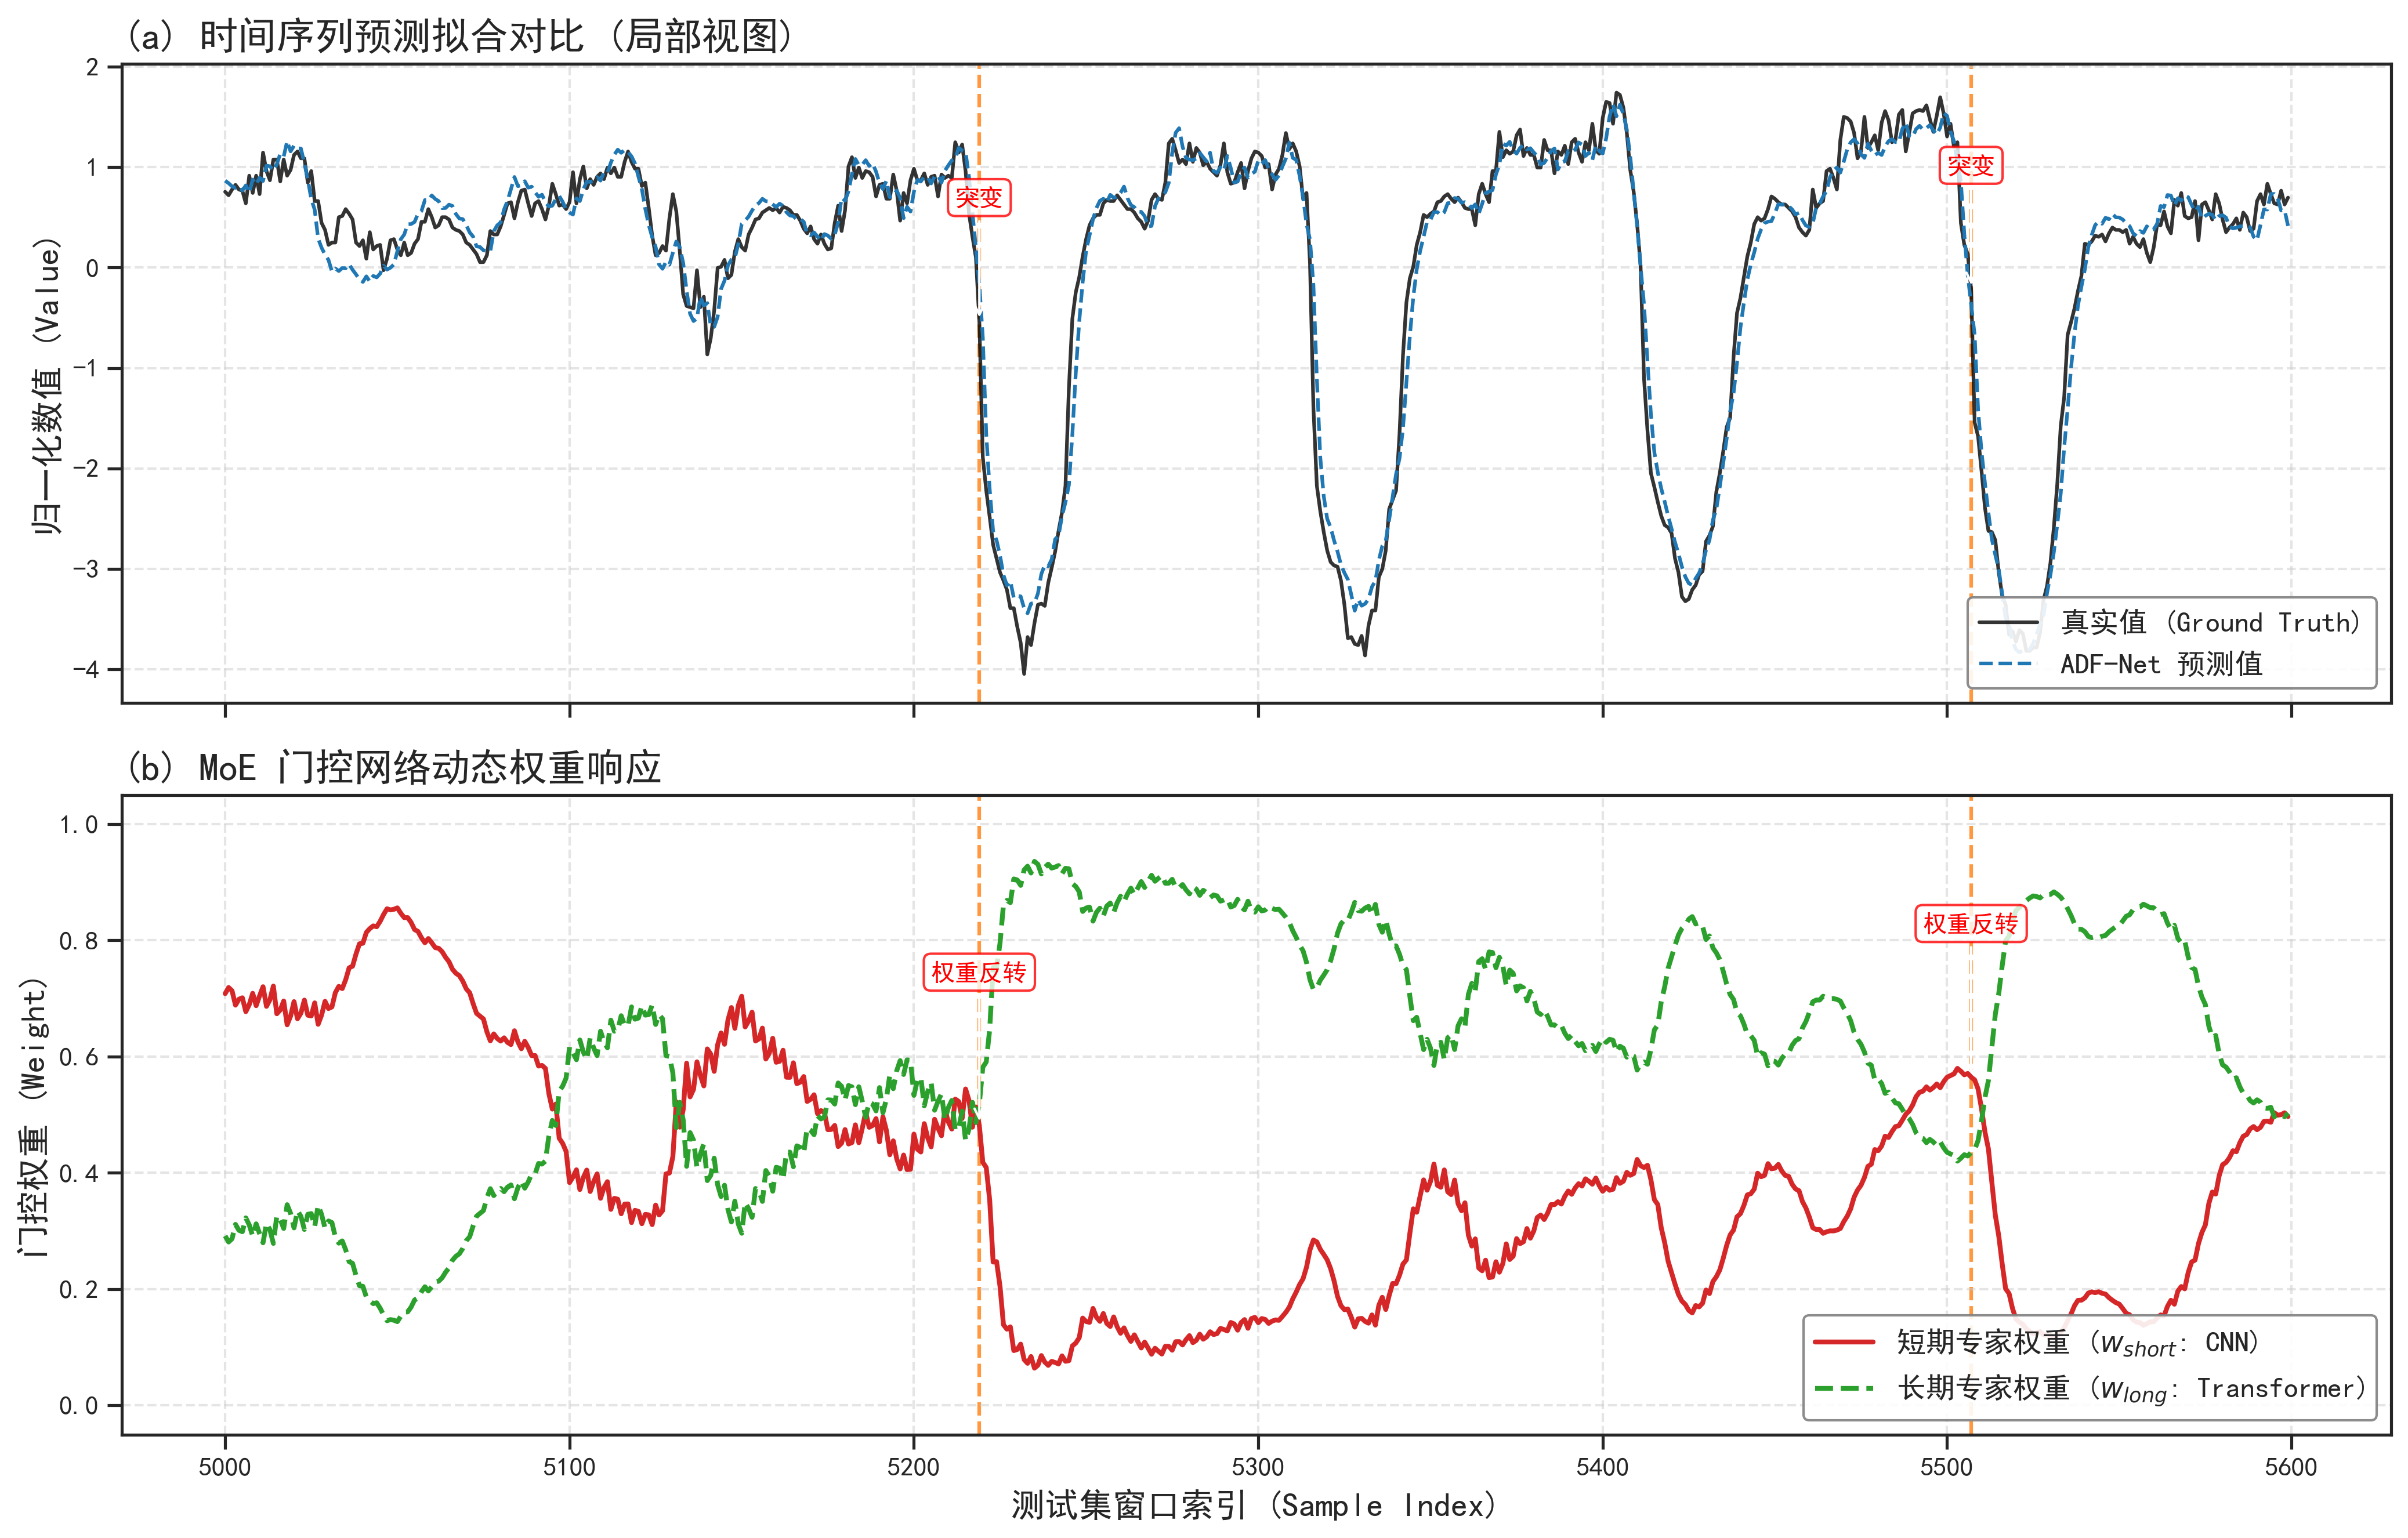

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 设置学术风格
sns.set(style="ticks")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 适配中文和英文
plt.rcParams['axes.unicode_minus'] = False

def plot_weight_analysis_with_vertical_lines(trues, preds, weights, start_idx=0, end_idx=None, save_path=None):
    """
    画出带有竖直对齐线的分析图
    """
    
    # --- 0. 数据预处理与切片 ---
    total_len = len(trues)
    if end_idx is None or end_idx > total_len:
        end_idx = total_len
    
    print(f"正在绘制区间: [{start_idx}, {end_idx}]")

    idx_step = 0 
    
    # 切片
    time_steps = np.arange(start_idx, end_idx)
    truth_series = trues[start_idx:end_idx, idx_step, 0]
    pred_series = preds[start_idx:end_idx, idx_step, 0]
    w_short = weights[start_idx:end_idx, 0, 0]
    w_long = weights[start_idx:end_idx, 0, 1]

    # --- 1. 创建画布 ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, dpi=300)
    
    # --- 图 A: 真实值 vs 预测值 ---
    ax1.plot(time_steps, truth_series, color='black', linewidth=1.5, alpha=0.8, label='真实值 (Ground Truth)')
    ax1.plot(time_steps, pred_series, color='#1f77b4', linewidth=1.5, linestyle='--', label='ADF-Net 预测值')
    
    ax1.set_ylabel('归一化数值 (Value)', fontsize=14)
    ax1.set_title('(a) 时间序列预测拟合对比 (局部视图)', fontsize=16, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='lower right', frameon=True, fontsize=12, facecolor='white', framealpha=0.9, edgecolor='gray')

    # --- 图 B: MoE 权重变化 ---
    ax2.plot(time_steps, w_short, color='#d62728', linewidth=2, label='短期专家权重 ($w_{short}$: CNN)')
    ax2.plot(time_steps, w_long, color='#2ca02c', linewidth=2, linestyle='--', label='长期专家权重 ($w_{long}$: Transformer)')
    
    ax2.set_ylabel('门控权重 (Weight)', fontsize=14)
    ax2.set_xlabel('测试集窗口索引 (Sample Index)', fontsize=14)
    ax2.set_title('(b) MoE 门控网络动态权重响应', fontsize=16, fontweight='bold', loc='left')
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right', frameon=True, fontsize=12, facecolor='white', framealpha=0.9, edgecolor='gray')

    # --- 2. 关联分析标记 (Storytelling) ---
    # 自动寻找切片内的突变点
    diff = np.abs(np.diff(truth_series))
    local_top_indices = np.argsort(diff)[-3:] # 找变化最大的3个点
    
    for local_idx in local_top_indices:
        global_idx = time_steps[local_idx]
        
        # 仅当短期权重较高时才画线 (避免在平稳期乱画线)
        if w_short[local_idx] > 0.4:
            
            # 【新增关键点】画竖直虚线，贯穿上下两图
            # axvline: 绘制垂直线
            # color='orange': 使用橙色作为高亮色，对比度好
            # zorder=0: 保证线在数据的后面，不要遮挡曲线
            ax1.axvline(x=global_idx, color='#ff7f0e', linestyle='--', alpha=0.8, linewidth=1.5, zorder=0)
            ax2.axvline(x=global_idx, color='#ff7f0e', linestyle='--', alpha=0.8, linewidth=1.5, zorder=0)
            
            # 标记箭头和文字 (保持之前的逻辑)
            ax1.annotate('突变', 
                         xy=(global_idx, truth_series[local_idx]), 
                         xytext=(global_idx, truth_series[local_idx] + (truth_series.max() - truth_series.min())*0.2),
                         arrowprops=dict(facecolor='black', arrowstyle='->'), 
                         fontsize=10, color='red', ha='center',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8)) # 给文字加个白底，防止看不清
            
            ax2.annotate('权重反转', 
                         xy=(global_idx, w_short[local_idx]), 
                         xytext=(global_idx, w_short[local_idx] + 0.25),
                         arrowprops=dict(facecolor='red', arrowstyle='->'), 
                         fontsize=10, color='red', ha='center',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"图像已保存至: {save_path}")
    
    plt.show()

# --- 加载数据并调用 ---
# 请替换为你的实际路径
trues = np.load('../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/true.npy')
preds = np.load('../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/pred.npy')
weights = np.load('../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/moe_weights_period_0.npy')

# 确保转为 numpy
if hasattr(trues, 'cpu'): trues = trues.cpu().numpy()
if hasattr(preds, 'cpu'): preds = preds.cpu().numpy()
if hasattr(weights, 'cpu'): weights = weights.cpu().numpy()

# 绘制局部区间 (请根据你的数据调整 start_idx 和 end_idx)
plot_weight_analysis_with_vertical_lines(trues, preds, weights, start_idx=5000, end_idx=5600, save_path='moe_analysis_lines.png')

正在绘制 [(短期预测 T=96)] 区间: [5000, 5600]
图像已保存至: moe_analysis_96.png


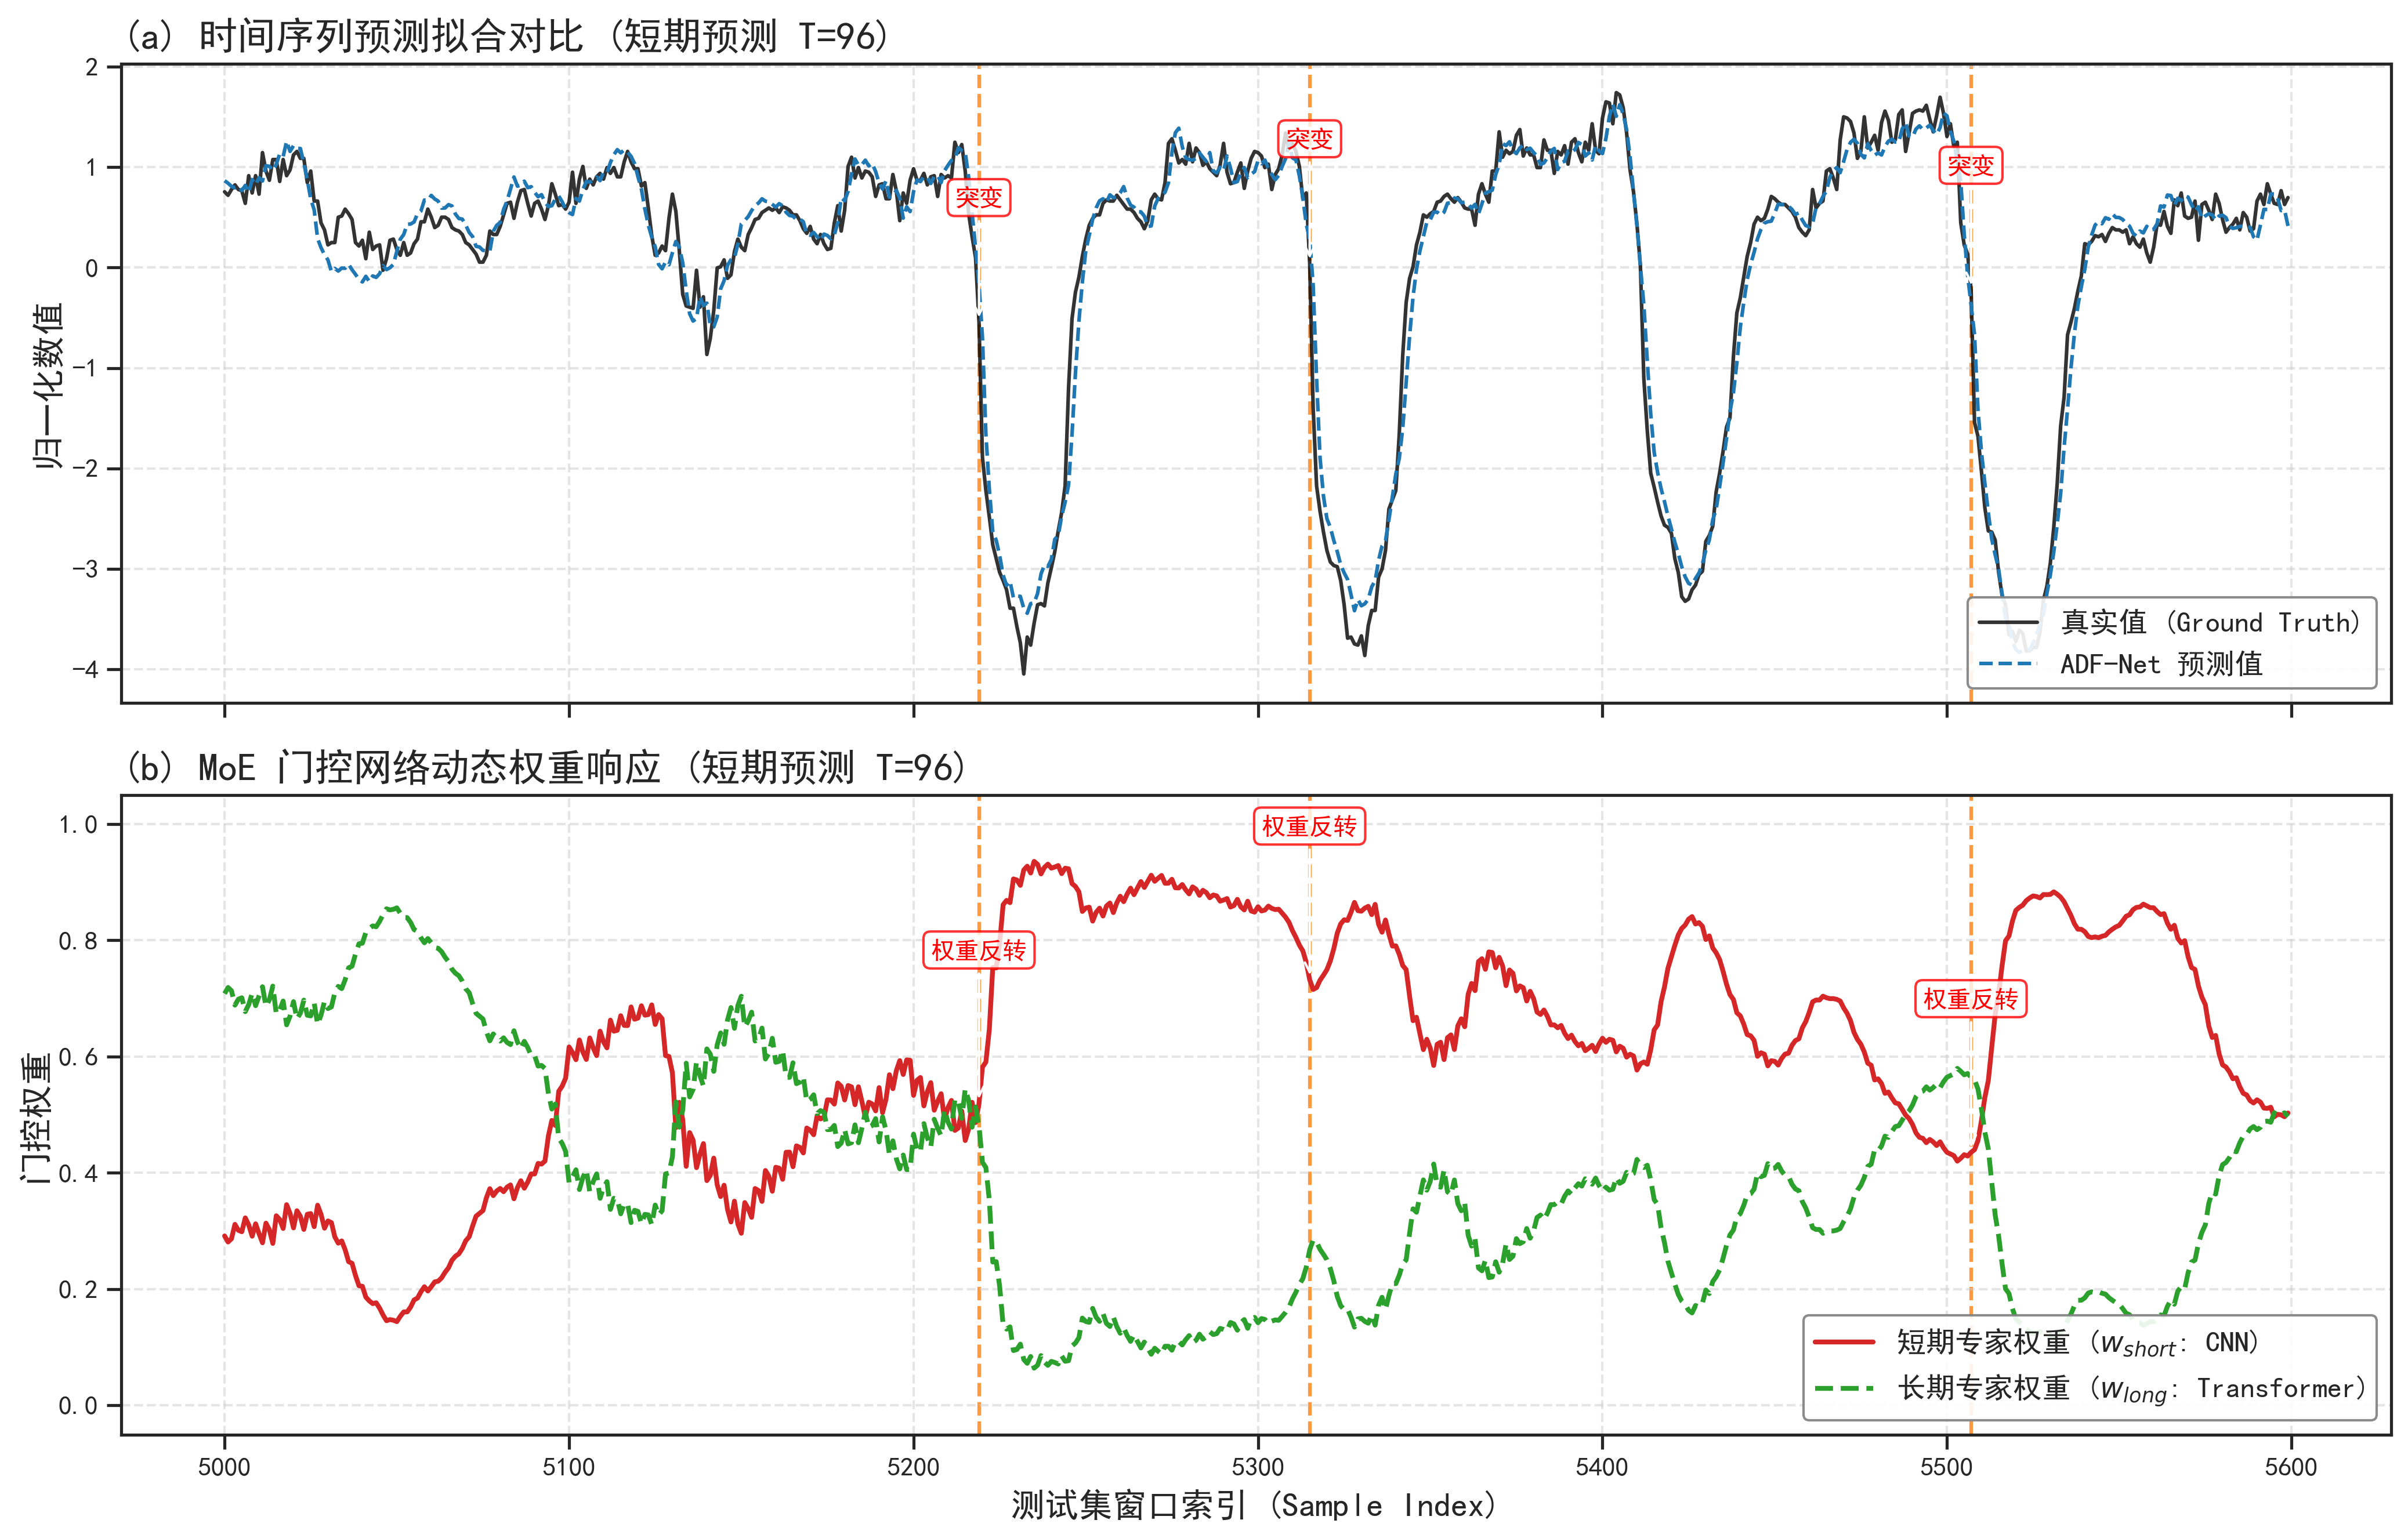

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# --- 1. 全局风格设置 ---
sns.set(style="ticks")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']  # 适配中文和英文
plt.rcParams['axes.unicode_minus'] = False

def plot_weight_analysis_with_vertical_lines(trues, preds, weights, title_suffix="", start_idx=0, end_idx=None, save_path=None):
    """
    绘制带有竖直对齐线的分析图，支持自定义标题后缀
    """
    
    # --- 数据预处理 ---
    total_len = len(trues)
    if end_idx is None or end_idx > total_len:
        end_idx = total_len
    
    print(f"正在绘制 [{title_suffix}] 区间: [{start_idx}, {end_idx}]")

    idx_step = 0 
    
    # 切片
    time_steps = np.arange(start_idx, end_idx)
    truth_series = trues[start_idx:end_idx, idx_step, 0]
    pred_series = preds[start_idx:end_idx, idx_step, 0]
    
    # 提取权重: index 0 -> Short(CNN), index 1 -> Long(Transformer)
    w_short = weights[start_idx:end_idx, 0, 1]
    w_long = weights[start_idx:end_idx, 0, 0]

    # --- 创建画布 ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, dpi=300)
    
    # --- 图 A: 真实值 vs 预测值 ---
    ax1.plot(time_steps, truth_series, color='black', linewidth=1.5, alpha=0.8, label='真实值 (Ground Truth)')
    ax1.plot(time_steps, pred_series, color='#1f77b4', linewidth=1.5, linestyle='--', label='ADF-Net 预测值')
    
    ax1.set_ylabel('归一化数值', fontsize=14)
    # 动态标题
    ax1.set_title(f'(a) 时间序列预测拟合对比 {title_suffix}', fontsize=16, fontweight='bold', loc='left')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='lower right', frameon=True, fontsize=12, facecolor='white', framealpha=0.9, edgecolor='gray')

    # --- 图 B: MoE 权重变化 ---
    ax2.plot(time_steps, w_short, color='#d62728', linewidth=2, label='短期专家权重 ($w_{short}$: CNN)')
    ax2.plot(time_steps, w_long, color='#2ca02c', linewidth=2, linestyle='--', label='长期专家权重 ($w_{long}$: Transformer)')
    
    ax2.set_ylabel('门控权重', fontsize=14)
    ax2.set_xlabel('测试集窗口索引 (Sample Index)', fontsize=14)
    ax2.set_title(f'(b) MoE 门控网络动态权重响应 {title_suffix}', fontsize=16, fontweight='bold', loc='left')
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right', frameon=True, fontsize=12, facecolor='white', framealpha=0.9, edgecolor='gray')

    # --- 关联分析标记 (Storytelling) ---
    # 自动寻找切片内的突变点
    diff = np.abs(np.diff(truth_series))
    # 找变化最大的3个点
    local_top_indices = np.argsort(diff)[-3:] 
    
    for local_idx in local_top_indices:
        global_idx = time_steps[local_idx]
        
        # 仅当短期权重较高时才画线 (避免在平稳期乱画线)
        if w_short[local_idx] > 0.4:
            
            # 画竖直虚线
            ax1.axvline(x=global_idx, color='#ff7f0e', linestyle='--', alpha=0.8, linewidth=1.5, zorder=0)
            ax2.axvline(x=global_idx, color='#ff7f0e', linestyle='--', alpha=0.8, linewidth=1.5, zorder=0)
            
            # 标记箭头和文字
            ax1.annotate('突变', 
                         xy=(global_idx, truth_series[local_idx]), 
                         xytext=(global_idx, truth_series[local_idx] + (truth_series.max() - truth_series.min())*0.2),
                         arrowprops=dict(facecolor='black', arrowstyle='->'), 
                         fontsize=10, color='red', ha='center',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
            
            ax2.annotate('权重反转', 
                         xy=(global_idx, w_short[local_idx]), 
                         xytext=(global_idx, w_short[local_idx] + 0.25),
                         arrowprops=dict(facecolor='red', arrowstyle='->'), 
                         fontsize=10, color='red', ha='center',
                         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"图像已保存至: {save_path}")
    
    plt.show()

# --- 2. 配置与执行部分 ---

# 定义两组实验的路径 (请替换为你实际的文件路径)
experiments = [
    {
        "name": "(短期预测 T=96)",
        "true_path": "../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/true.npy", # 替换实际路径
        "pred_path": "../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/pred.npy", # 替换实际路径
        "weight_path": "../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/moe_weights_period_0.npy", # 替换实际路径
        "save_name": "moe_analysis_96.png"
    },
    # {
    #     "name": "(长期预测 T=720)",
    #     "true_path": "../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/true.npy", # 替换实际路径
    #     "pred_path": "../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/pred.npy", # 替换实际路径
    #     "weight_path": "../results/ETTm1_720_96_ADF_ETTm1_ftM_sl720_ll48_pl96_dm48_nh16_el3_dl1_df48_fc1_ebtimeF_dtTrue_Exp_0/moe_weights_period_1.npy", # 替换实际路径
    #     "save_name": "moe_analysis_720.png"
    # }
]

# 统一的绘图区间 (确保长短期对比的是同一段时间段)
# 注意：确保这个区间在两个文件中都存在
START_IDX = 5000
END_IDX = 5600

for exp in experiments:
    # 检查文件是否存在
    if os.path.exists(exp["true_path"]) and os.path.exists(exp["weight_path"]):
        # 加载数据
        trues = np.load(exp["true_path"])
        preds = np.load(exp["pred_path"])
        weights = np.load(exp["weight_path"])
        
        # 转换格式
        if hasattr(trues, 'cpu'): trues = trues.cpu().numpy()
        if hasattr(preds, 'cpu'): preds = preds.cpu().numpy()
        if hasattr(weights, 'cpu'): weights = weights.cpu().numpy()
        
        # 绘图
        plot_weight_analysis_with_vertical_lines(
            trues, preds, weights, 
            title_suffix=exp["name"], 
            start_idx=START_IDX, 
            end_idx=END_IDX, 
            save_path=exp["save_name"]
        )
    else:
        print(f"文件缺失，跳过: {exp['name']}")
        # print(f"请检查路径: {exp['weight_path']}")